---
### 02. Tensor
---

In [7]:
import numpy as np
import pandas as pd
import torch

# Google Drive 연결, 작업공간 설정
from google.colab import drive
import os
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/10Days_Pytorch')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#### 1~4차원 텐서

In [8]:
scalar = torch.tensor(5)
print(scalar, scalar.shape)

tensor(5) torch.Size([])


In [9]:
vector = torch.tensor([1,2,3,4])
print(vector, vector.shape)

tensor([1, 2, 3, 4]) torch.Size([4])


In [10]:
matrix = torch.tensor([
    [1,2,3],
    [4,5,6]
])
print(matrix, matrix.shape)

tensor([[1, 2, 3],
        [4, 5, 6]]) torch.Size([2, 3])


In [11]:
tensor3d = torch.rand(2,3,4)
print(tensor3d, tensor3d.shape)

tensor([[[0.8537, 0.3155, 0.3875, 0.5302],
         [0.4029, 0.5011, 0.6251, 0.8827],
         [0.6007, 0.5336, 0.8663, 0.3245]],

        [[0.1769, 0.3893, 0.0923, 0.9595],
         [0.6026, 0.2354, 0.8447, 0.5210],
         [0.2543, 0.3825, 0.7331, 0.4754]]]) torch.Size([2, 3, 4])


#### 텐서 연산

In [12]:
# 1) 사칙연산
a = torch.tensor([1,2,3])
b = torch.tensor([4,5,6])

print(a+b)
print(a-b)
print(a*b)
print(a**2)

tensor([5, 7, 9])
tensor([-3, -3, -3])
tensor([ 4, 10, 18])
tensor([1, 4, 9])


In [13]:
# 1) 기본연산
x = torch.tensor([
    [1,2,3], [4,5,6]
], dtype=torch.float32)

x

tensor([[1., 2., 3.],
        [4., 5., 6.]])

In [14]:
print('전체합계 =', x.sum())
print('최대값 =', x.max())
print('최소값 =', x.min())
print('평균 =', x.mean())

print('컬럼별 합계 =', x.sum(dim=1))
print('행별 합계 =', x.sum(dim=0))

전체합계 = tensor(21.)
최대값 = tensor(6.)
최소값 = tensor(1.)
평균 = tensor(3.5000)
컬럼별 합계 = tensor([ 6., 15.])
행별 합계 = tensor([5., 7., 9.])


In [15]:
# 2) 차원변경
x = torch.tensor([
    [1,2], [3,4], [5,6]
])
x

tensor([[1, 2],
        [3, 4],
        [5, 6]])

In [16]:
x.view(2,3)

tensor([[1, 2, 3],
        [4, 5, 6]])

In [17]:
# 텐서 연결
x1 = torch.tensor([
    [1,2], [3,4]
])

x2 = torch.tensor([
    [5,6]
])

torch.cat([x1,x2], dim=0)

tensor([[1, 2],
        [3, 4],
        [5, 6]])

In [18]:
# 텐서 분리
x3 = torch.tensor([1,2,3,4,5,6,7,8])
s1, s2 = torch.split(x3, 4)
print(s2, s2)

tensor([5, 6, 7, 8]) tensor([5, 6, 7, 8])


In [19]:
# 점곱(dot product)
a = torch.tensor([1,2,3])
b = torch.tensor([4,5,6])
torch.dot(a,b)

tensor(32)

In [20]:
# 행렬곱(matrix multiplication)
A = torch.tensor([
    [1,2], [3,4]
])

B = torch.tensor([
    [5,6], [7,8]
])

torch.matmul(A,B)

tensor([[19, 22],
        [43, 50]])

#### Data loader

In [21]:
df = pd.read_csv('data/advertising.csv')

y = df['Sales']
X = df.drop('Sales', axis=1)

print(type(X))
print(type(X.values))

<class 'pandas.core.frame.DataFrame'>
<class 'numpy.ndarray'>


In [22]:
# 텐서변환
X_tensor = torch.tensor(X.values, dtype=torch.float32)
y_tensor = torch.tensor(y.values, dtype=torch.float32)
print(X_tensor.shape, y_tensor.shape)

torch.Size([200, 3]) torch.Size([200])


In [23]:
# 텐서 데이터셋
from torch.utils.data import TensorDataset
dataset = TensorDataset(X_tensor, y_tensor)
print(dataset[:5])

(tensor([[230.1000,  37.8000,  69.2000],
        [ 44.5000,  39.3000,  45.1000],
        [ 17.2000,  45.9000,  69.3000],
        [151.5000,  41.3000,  58.5000],
        [180.8000,  10.8000,  58.4000]]), tensor([22.1000, 10.4000,  9.3000, 18.5000, 12.9000]))


In [24]:
# Data loader
from torch.utils.data import DataLoader
data_loader = DataLoader(dataset, batch_size=32, shuffle=True)

#### Device 할당

In [25]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [26]:
# dataset 디바이스 할당
X, y = X_tensor.to(device), y_tensor.to(device)

print(X.device, y.device)

cuda:0 cuda:0


In [27]:
# model 디바이스 할당
from torch import nn
model = nn.Sequential(nn.Linear(3,1))
model = model.to(device)

print(next(model.parameters()).device)

cuda:0


In [31]:
# device 전환
X1 = X.to('cpu')
print('X1:', X1.device)

X2 = X1.to('cuda')
print('X2:', X2.device)

X1: cpu
X2: cuda:0


In [28]:
# [예시] 모델 검증시 텐서 -> 넘파이 변환
pred = pred.cpu().numpy()
y_valid = y_valid.cpu().numpy()
rmse = root_mean_absolute_error(y_valid, pred)

---
#### 참고. 가중치 업데이트 시각화 (더미 데이터&모델)

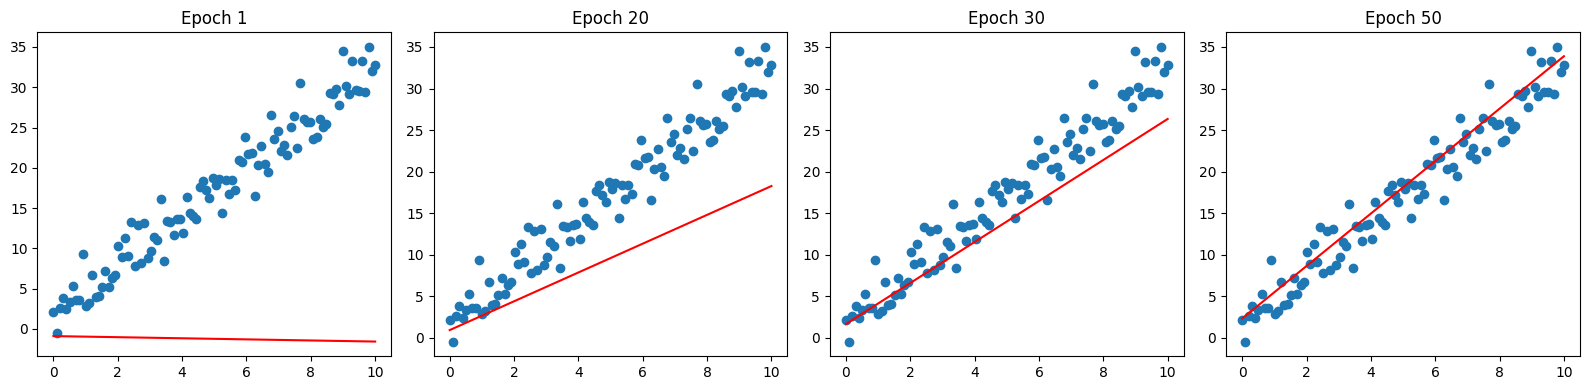

In [52]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 데이터
x = torch.linspace(0, 10, 100).view(-1, 1)
y = 3 * x + 2 + torch.randn_like(x) * 2.0

# 모델
model = nn.Linear(1, 1)

# 설정
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.1)

# 저장 epoch
check_epochs = [1, 20, 30, 50]
pred_dict = {}

EPOCHS = 50

# 학습
for epoch in range(1, EPOCHS+1):
    pred = model(x)
    loss = loss_fn(pred, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch in check_epochs:
        pred_dict[epoch] = pred.detach().numpy()

# 🔹 시각화
fig, axes = plt.subplots(1, 4, figsize=(16,4))

for i, ep in enumerate(check_epochs):
    ax = axes[i]
    ax.scatter(x.numpy(), y.numpy())
    ax.plot(x.numpy(), pred_dict[ep], color='red')
    ax.set_title(f'Epoch {ep}')

plt.tight_layout()
plt.show()